In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import sys

In [8]:
df = pd.read_csv('/content/train.csv')
text = " ".join(df['text'].dropna().astype(str)).lower()

print(f'Total characters in text: {len(text)}')

Total characters in text: 35695884


In [9]:
vocab = sorted(set(text))
print(f'Vocabulary size: {len(vocab)}')

char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

Vocabulary size: 104


In [10]:
seq_length = 100

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    return chunk[:-1], chunk[1:]

dataset = sequences.map(split_input_target)

BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

In [11]:
vocab_size = len(vocab)
embedding_dim = 64
rnn_units = 128

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_shape=(None,)),
    tf.keras.layers.LSTM(rnn_units, return_sequences=True, recurrent_initializer='glorot_uniform'),
    tf.keras.layers.Dense(vocab_size)
])


def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model.compile(optimizer='adam', loss=loss)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 104)      │        13,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,888 (464.41 KB)

 Trainable params: 118,888 (464.41 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 20
history = model.fit(dataset, epochs=EPOCHS)

Epoch 1/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 103s 18ms/step - loss: 2.1123
Epoch 2/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 97s 17ms/step - loss: 1.4875
Epoch 3/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 140s 17ms/step - loss: 1.3995
Epoch 4/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 139s 16ms/step - loss: 1.3625
Epoch 5/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.3415
Epoch 6/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 142s 16ms/step - loss: 1.3274
Epoch 7/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 93s 16ms/step - loss: 1.3169
Epoch 8/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 93s 17ms/step - loss: 1.3089
Epoch 9/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 93s 16ms/step - loss: 1.3025
Epoch 10/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 94s 17ms/step - loss: 1.2972
Epoch 11/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2930
Epoch 12/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 96s 17ms/step - loss: 1.2894
Epoch 13/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2862
Epoch 14/20
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.28

In [13]:
def generate_text(model, start_string, num_generate=100, temperature=1.0):
    input_eval = [char2idx.get(s, 0) for s in start_string.lower()]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    model.layers[1].reset_states()

    for _ in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0) / temperature
        predicted_id = tf.random.categorical(
            predictions, num_samples=1)[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)


print(generate_text(model, start_string="The ", num_generate=200, temperature=0.8))

The chitor t e ster tat s r w ve thabuthatst ofld ine ithateredat cl ateliande gllone jovite corrs blisin af theicout t tanive an ctora orive r peron cts torof pppen thes pesthes be sofoks p ticoof orate 


In [14]:
history2 = model.fit(dataset, epochs=40)

Epoch 1/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 96s 17ms/step - loss: 1.2702
Epoch 2/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2690
Epoch 3/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 95s 17ms/step - loss: 1.2679
Epoch 4/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 139s 16ms/step - loss: 1.2666
Epoch 5/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2656
Epoch 6/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 90s 16ms/step - loss: 1.2648
Epoch 7/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 144s 16ms/step - loss: 1.2638
Epoch 8/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2628
Epoch 9/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 91s 16ms/step - loss: 1.2622
Epoch 10/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 95s 17ms/step - loss: 1.2613
Epoch 11/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 140s 17ms/step - loss: 1.2607
Epoch 12/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 100s 18ms/step - loss: 1.2600
Epoch 13/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.2594
Epoch 14/40
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - loss: 1.25

In [15]:
def generate_text(model, start_string, num_generate=100, temperature=1.0):
    input_eval = [char2idx.get(s, 0) for s in start_string.lower()]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    model.layers[1].reset_states()

    for _ in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0) / temperature
        predicted_id = tf.random.categorical(
            predictions, num_samples=1)[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)


print(generate_text(model, start_string="The ", num_generate=200, temperature=0.8))

The umal tron tsithicon thabe s 5, ig t wiora ont t congysheand perors tonss s at ane wir till sictithitorngine at are f a thal ivadesalyervand ce d widem tilicalaten ciry omenovead f bid in by s atse lei


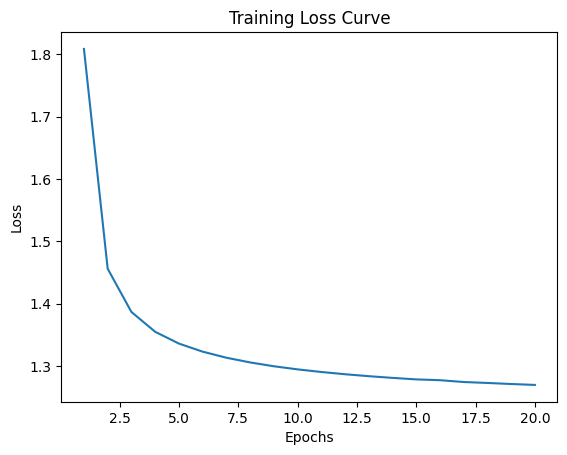

In [24]:
import matplotlib.pyplot as plt

losses = history.history['loss']

plt.plot(range(1, len(losses)+1), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [25]:
import math
perplexity = math.exp(1.2493)
print(perplexity)


3.4879005723261467
